Import Library

In [ ]:
# Import Library
import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

from scipy.cluster.hierarchy import dendrogram

import seaborn as sns

from sklearn.cluster import AgglomerativeClustering

from sklearn.cluster import (
  AgglomerativeClustering,
  KMeans,
)
from sklearn.decomposition import PCA
from sklearn.metrics import (
  calinski_harabasz_score,
  silhouette_samples,
  silhouette_score,
)
from sklearn.metrics.cluster import (
  adjusted_rand_score,
  rand_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_style({
    'axes.facecolor': '#f3f3f3ff',
    'figure.facecolor': '#f3f3f3ff',
})

In [ ]:
# Read dataset
df = pd.read_csv('/content/flight.csv')

In [ ]:
# Row and column
df.shape

(62988, 23)

In [ ]:
df.sample(5)

,MEMBER_NO,FFP_DATE,FIRST_FLIGHT_DATE,GENDER,FFP_TIER,WORK_CITY,WORK_PROVINCE,WORK_COUNTRY,AGE,LOAD_TIME,...,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
26243,14438,9/19/2011,9/19/2011,Male,4,beijing,beijing,CN,45.0,3/31/2014,...,2742.0,15593,10/17/2013,167,51.000000,102,0,0.575186,7891,0
39016,10177,3/1/2007,5/15/2008,Female,4,foshan,guangdong,CN,NaN,3/31/2014,...,1194.0,8421,8/24/2013,221,72.666667,147,0,0.578853,3481,0
20744,51827,9/6/2012,9/6/2012,Male,4,jinan,shandong,CN,58.0,3/31/2014,...,5545.0,13859,3/17/2014,15,39.857143,110,0,0.851617,11636,0
43744,52834,2/13/2012,2/25/2012,Male,4,Geumjeong-gu,Busan,KR,48.0,3/31/2014,...,0.0,4640,1/11/2013,446,39.714286,76,0,0.831250,3400,0
17964,11045,2/1/2005,7/2/2006,Male,4,beijing,beijing,CN,47.0,3/31/2014,...,10876.0,17010,2/26/2014,35,39.588235,153,0,0.801272,12479,0


In [ ]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62988 entries, 0 to 62987
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MEMBER_NO          62988 non-null  int64  
 1   FFP_DATE           62988 non-null  object 
 2   FIRST_FLIGHT_DATE  62988 non-null  object 
 3   GENDER             62985 non-null  object 
 4   FFP_TIER           62988 non-null  int64  
 5   WORK_CITY          60719 non-null  object 
 6   WORK_PROVINCE      59740 non-null  object 
 7   WORK_COUNTRY       62962 non-null  object 
 8   AGE                62568 non-null  float64
 9   LOAD_TIME          62988 non-null  object 
 10  FLIGHT_COUNT       62988 non-null  int64  
 11  BP_SUM             62988 non-null  int64  
 12  SUM_YR_1           62437 non-null  float64
 13  SUM_YR_2           62850 non-null  float64
 14  SEG_KM_SUM         62988 non-null  int64  
 15  LAST_FLIGHT_DATE   62988 non-null  object 
 16  LAST_TO_END        629

In [ ]:
# Check missing value
df.isna().sum()

,0
MEMBER_NO,0
FFP_DATE,0
FIRST_FLIGHT_DATE,0
GENDER,3
FFP_TIER,0
WORK_CITY,2269
WORK_PROVINCE,3248
WORK_COUNTRY,26
AGE,420
LOAD_TIME,0


In [ ]:
# Drop column
df = df.drop(columns=['MEMBER_NO', 'WORK_CITY', 'WORK_PROVINCE', 'WORK_COUNTRY', 'FIRST_FLIGHT_DATE'])

kolom Member no didrop karena hanya ID unik pelanggan, sehingga jika tidak didrop hanya akan membuat K-Means bingung karena ID unik tidak memiliki pola

kolom Work_city, Work_province, work_country didrop dikarenakan memiliki sangat banyak kategori, jarak antar kategori tidak memiliki arti numerik sehingga akan membuat cluster yang tidak baik untuk penginpretasian

kolom first flight date didrop karena akan dibentuk kolom tenure and recency dengan FFP_Date dan Last_flight_date

In [ ]:
# Presentase missing value
((df.isna().sum())/len(df))*100

,0
FFP_DATE,0.000000
GENDER,0.004763
FFP_TIER,0.000000
AGE,0.666794
LOAD_TIME,0.000000
FLIGHT_COUNT,0.000000
BP_SUM,0.000000
SUM_YR_1,0.874770
SUM_YR_2,0.219089
SEG_KM_SUM,0.000000


Berdasarkan data gender, age, sum yr 1 dan sum yr 2 memiliki missing value < 20% sehingga dapat dihandling missing value dengan median atau modus

In [ ]:
# Gender
if df['GENDER'].isna().sum() > 0:
    df['GENDER'] = df['GENDER'].fillna(df['GENDER'].mode()[0])

# Age
if df['AGE'].isna().sum() > 0:
    df['AGE'] = df['AGE'].fillna(df['AGE'].median())

# SUM_YR_1 & SUM_YR_2
for col in ['SUM_YR_1', 'SUM_YR_2']:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [ ]:
# Check missing value
df.isna().sum()

,0
FFP_DATE,0
GENDER,0
FFP_TIER,0
AGE,0
LOAD_TIME,0
FLIGHT_COUNT,0
BP_SUM,0
SUM_YR_1,0
SUM_YR_2,0
SEG_KM_SUM,0


In [ ]:
# Check duplicates
df.duplicated().sum()

np.int64(1)

In [ ]:
# drop duplicate
df= df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Kolom yang bersifat kategorikal (bukan numerik)
df.select_dtypes(include=['object']).head()

,FFP_DATE,GENDER,LOAD_TIME,LAST_FLIGHT_DATE
0,11/2/2006,Male,3/31/2014,3/31/2014
1,2/19/2007,Male,3/31/2014,3/25/2014
2,2/1/2007,Male,3/31/2014,3/21/2014
3,8/22/2008,Male,3/31/2014,12/26/2013
4,4/10/2009,Male,3/31/2014,3/27/2014


In [ ]:
# Convert kolom tanggal ke datetime
date_cols = ['FFP_DATE', 'LOAD_TIME', 'LAST_FLIGHT_DATE']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [ ]:
df[date_cols].isna().sum()

,0
FFP_DATE,0
LOAD_TIME,0
LAST_FLIGHT_DATE,421


In [ ]:
df['LAST_FLIGHT_DATE'] = df['LAST_FLIGHT_DATE'].fillna(df['FFP_DATE'])

In [ ]:
df['LAST_FLIGHT_DATE'].isna().sum()

np.int64(0)

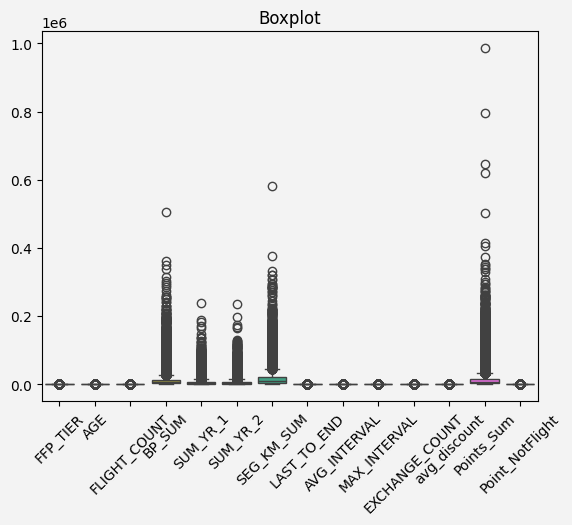

In [ ]:
# Check outlier
numeric_all = df.select_dtypes(include=['number'])
sns.boxplot(numeric_all)
plt.xticks(rotation=45)
plt.title('Boxplot')
plt.show()

Dalam hal ini dapat dilihat terdapat banyak outlier disetiap koom, namun dalam hal ini yang ingin diketahui untuk lebih memahami pelanggan

In [ ]:
# Check data distribution
df.describe()

,FFP_DATE,FFP_TIER,AGE,LOAD_TIME,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_FLIGHT_DATE,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
count,62987,62987.000000,62987.000000,62987,62987.000000,62987.000000,62987.000000,62987.000000,62987.000000,62987,62987.000000,62987.000000,62987.000000,62987.000000,62987.000000,62987.000000,62987.000000
mean,2010-03-06 23:38:30.591074560,4.102164,42.466541,2014-03-31 00:00:00,11.839570,10925.225475,5333.068955,5597.912410,17124.073650,2013-09-27 06:57:28.825948160,176.113500,67.750752,166.036420,0.319780,0.721560,12545.947053,2.728198
min,2004-11-01 00:00:00,4.000000,6.000000,2014-03-31 00:00:00,2.000000,0.000000,0.000000,0.000000,368.000000,2004-11-09 00:00:00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2008-04-12 00:00:00,4.000000,35.000000,2014-03-31 00:00:00,3.000000,2518.000000,1020.000000,785.000000,4747.000000,2013-07-01 00:00:00,29.000000,23.370370,79.000000,0.000000,0.612002,2775.000000,0.000000
50%,2010-10-08 00:00:00,4.000000,41.000000,2014-03-31 00:00:00,7.000000,5700.000000,2800.000000,2773.000000,9994.000000,2013-12-13 00:00:00,108.000000,44.666667,143.000000,0.000000,0.711857,6329.000000,0.000000
75%,2012-03-29 00:00:00,4.000000,48.000000,2014-03-31 00:00:00,15.000000,12831.000000,6524.500000,6826.500000,21271.500000,2014-03-03 00:00:00,267.500000,82.000000,228.000000,0.000000,0.809480,14303.000000,1.000000
max,2013-03-31 00:00:00,6.000000,110.000000,2014-03-31 00:00:00,213.000000,505308.000000,239560.000000,234188.000000,580717.000000,2014-03-31 00:00:00,731.000000,728.000000,728.000000,46.000000,1.500000,985572.000000,140.000000
std,NaN,0.373859,9.853706,NaN,14.049528,16339.575767,8077.463629,8694.872829,20960.953906,NaN,183.816213,77.518103,123.396532,1.136013,0.185427,20507.935139,7.364214


In [ ]:
# Check multicollinearity
df_corr = numeric_all.corr()
df_corr

,FFP_TIER,AGE,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight
FFP_TIER,1.000000,0.078514,0.582446,0.581084,0.463403,0.611306,0.522350,-0.206312,-0.144932,-0.127648,0.342355,0.248844,0.559249,0.192802
AGE,0.078514,1.000000,0.073344,0.100309,0.111727,0.083394,0.087213,-0.025633,-0.024553,0.009407,0.029753,0.132518,0.074717,-0.091931
FLIGHT_COUNT,0.582446,0.073344,1.000000,0.788378,0.748020,0.794825,0.850411,-0.404992,-0.316844,-0.188699,0.502500,0.139371,0.747090,0.291877
BP_SUM,0.581084,0.100309,0.788378,1.000000,0.850578,0.884614,0.921724,-0.319032,-0.246772,-0.147966,0.530020,0.307241,0.923270,0.244252
SUM_YR_1,0.463403,0.111727,0.748020,0.850578,1.000000,0.663371,0.803999,-0.188056,-0.241230,-0.141601,0.487949,0.267533,0.788412,0.235212
SUM_YR_2,0.611306,0.083394,0.794825,0.884614,0.663371,1.000000,0.849145,-0.423436,-0.245726,-0.153909,0.468232,0.234376,0.826689,0.238023
SEG_KM_SUM,0.522350,0.087213,0.850411,0.921724,0.803999,0.849145,1.000000,-0.369504,-0.280755,-0.155522,0.507818,0.108388,0.853014,0.259034
LAST_TO_END,-0.206312,-0.025633,-0.404992,-0.319032,-0.188056,-0.423436,-0.369504,1.000000,-0.108571,-0.343911,-0.169714,-0.021013,-0.292021,-0.124066
AVG_INTERVAL,-0.144932,-0.024553,-0.316844,-0.246772,-0.241230,-0.245726,-0.280755,-0.108571,1.000000,0.724389,-0.130231,-0.038823,-0.220954,-0.075972
MAX_INTERVAL,-0.127648,0.009407,-0.188699,-0.147966,-0.141601,-0.153909,-0.155522,-0.343911,0.724389,1.000000,-0.089424,-0.016406,-0.135990,-0.042851


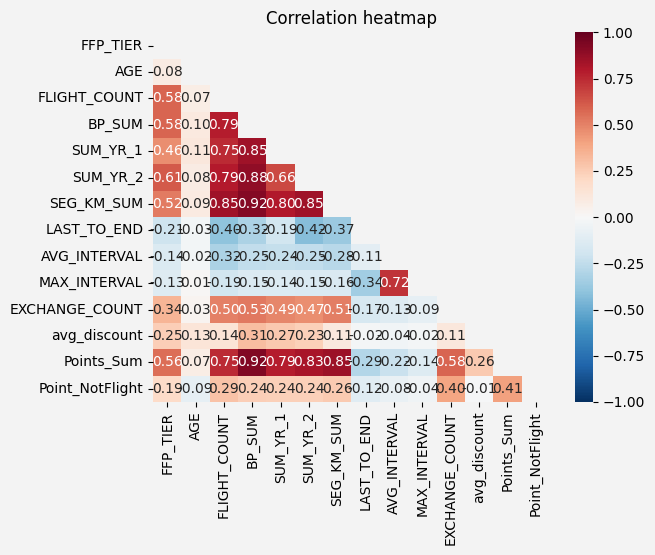

In [ ]:
mask = np.zeros_like(df_corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
  df_corr,
  vmin=-1,
  vmax=1,
  annot=True,
  fmt='.2f',
  mask=mask,
  cmap='RdBu_r',
)
plt.title('Correlation heatmap')
plt.show()

Berdasarkan heatmap dapat dilihat bahwa:
- SUM_YR_1, SUM_YR_2, SEG_KM_SUM, Points_Sum memiliki korelasi yang sangat tinggi (0.8-0.9). sehingga dapat dilihat adanya korelasi antara banyaknya point dengan jarak yang telah dijalani
- FLIGHT_COUNT berkorelasi tinggi dengan SEG_KM_SUM & SUM_YR_1 sehingga semakin sering melakukan penerbangan, semakin jauh serta semakin banuak point yang didapat
- kolom age korelasinya sangat rendah hampir ke semua fitur menunjukan bahwa usia tidak banyak menjelaskan terkait perilaku penerbangan customer

In [ ]:
# Preprocessing data
# Feature engineering dari tanggal & perilaku
# Menentukan berapa lama customer menjadi anggota loyality maskapai
df['TENURE_DAYS'] = (df['LOAD_TIME'] - df['FFP_DATE']).dt.days

In [ ]:
# Menentukan lama sejak customer terakhir melakukan penerbangan
df['RECENCY_DAYS'] = (df['LOAD_TIME'] - df['LAST_FLIGHT_DATE']).dt.days

In [ ]:
# Menentukan berapa kali customer terbang per tahun
df['FLIGHT_FREQUENCY'] = np.where(
  df['TENURE_DAYS'] > 0,
  df['FLIGHT_COUNT'] / (df['TENURE_DAYS'] / 365.25),
  0,
)

In [ ]:
# Menentukan rata-rata jarak penerbangan
df['AVG_DISTANCE_PER_FLIGHT'] = np.where(
  df['FLIGHT_COUNT'] > 0,
  df['SEG_KM_SUM'] / df['FLIGHT_COUNT'],
  0,
)

In [ ]:
# Presentase point customer yang tidak digunakan
df['UNUSED_POINT_RATIO'] = np.where(
  df['Points_Sum'] > 0,
  df['Point_NotFlight'] / df['Points_Sum'],
  0,
)

In [ ]:
features = [
  'FFP_TIER',
  'AGE',
  'FLIGHT_COUNT',
  'BP_SUM',
  'SUM_YR_1',
  'SUM_YR_2',
  'SEG_KM_SUM',
  'LAST_TO_END',
  'AVG_INTERVAL',
  'MAX_INTERVAL',
  'EXCHANGE_COUNT',
  'avg_discount',
  'Points_Sum',
  'Point_NotFlight',
  'TENURE_DAYS',
  'RECENCY_DAYS',
  'FLIGHT_FREQUENCY',
  'AVG_DISTANCE_PER_FLIGHT',
  'UNUSED_POINT_RATIO',
  ]

X = df[features].copy()
X.head()

,FFP_TIER,AGE,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight,TENURE_DAYS,RECENCY_DAYS,FLIGHT_FREQUENCY,AVG_DISTANCE_PER_FLIGHT,UNUSED_POINT_RATIO
0,6,31.0,210,505308,239560.0,234188.0,580717,1,3.483254,18,34,0.961639,619760,50,2706,0,28.345344,2765.319048,0.000081
1,6,42.0,140,362480,171483.0,167434.0,293678,7,5.194245,17,29,1.252314,415768,33,2597,6,19.690027,2097.700000,0.000079
2,6,40.0,135,351159,163618.0,164982.0,283712,11,5.298507,18,20,1.254676,406361,26,2615,10,18.856119,2101.570370,0.000064
3,5,64.0,23,337314,116350.0,125500.0,281336,97,27.863636,73,11,1.090870,372204,12,2047,95,4.103933,12232.000000,0.000032
4,6,48.0,152,273844,124560.0,130702.0,309928,5,4.788079,47,27,0.970658,338813,39,1816,4,30.571586,2039.000000,0.000115


In [ ]:
# Transformation
X_transformed = X.copy()
X_transformed.head(3)

,FFP_TIER,AGE,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight,TENURE_DAYS,RECENCY_DAYS,FLIGHT_FREQUENCY,AVG_DISTANCE_PER_FLIGHT,UNUSED_POINT_RATIO
0,6,31.0,210,505308,239560.0,234188.0,580717,1,3.483254,18,34,0.961639,619760,50,2706,0,28.345344,2765.319048,0.000081
1,6,42.0,140,362480,171483.0,167434.0,293678,7,5.194245,17,29,1.252314,415768,33,2597,6,19.690027,2097.700000,0.000079
2,6,40.0,135,351159,163618.0,164982.0,283712,11,5.298507,18,20,1.254676,406361,26,2615,10,18.856119,2101.570370,0.000064


In [ ]:
# Standardscaler
float64_columns = X_transformed.columns

for c in float64_columns:
  scaler = StandardScaler()
  X_transformed[c] = scaler.fit_transform(X_transformed[[c]])

X_transformed.describe()

,FFP_TIER,AGE,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight,TENURE_DAYS,RECENCY_DAYS,FLIGHT_FREQUENCY,AVG_DISTANCE_PER_FLIGHT,UNUSED_POINT_RATIO
count,6.298700e+04,6.298700e+04,6.298700e+04,6.298700e+04,6.298700e+04,6.298700e+04,6.298700e+04,6.298700e+04,6.298700e+04,6.298700e+04,6.298700e+04,6.298700e+04,6.298700e+04,6.298700e+04,6.298700e+04,6.298700e+04,6.298700e+04,6.298700e+04,6.298700e+04
mean,-7.977770e-16,-1.588334e-16,-2.887881e-17,4.331821e-17,3.609851e-17,-5.775761e-17,-5.053791e-17,-2.887881e-17,-6.497732e-17,-5.053791e-17,5.775761e-17,1.660531e-16,7.219702e-17,3.609851e-18,-1.010758e-16,-1.443940e-17,-5.053791e-17,1.660531e-16,3.609851e-18
std,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00
min,-2.732710e-01,-3.700824e+00,-7.003544e-01,-6.686411e-01,-6.602458e-01,-6.438227e-01,-7.994010e-01,-9.526629e-01,-8.740060e-01,-1.345562e+00,-2.814958e-01,-3.891362e+00,-6.117655e-01,-3.704699e-01,-1.321995e+00,-8.128701e-01,-7.553069e-01,-1.240433e+00,-1.111747e-01
25%,-2.732710e-01,-7.577454e-01,-6.291770e-01,-5.145355e-01,-5.339675e-01,-5.535389e-01,-5.904871e-01,-8.003356e-01,-5.725209e-01,-7.053449e-01,-2.814958e-01,-5.908457e-01,-4.764509e-01,-3.704699e-01,-8.888115e-01,-6.896480e-01,-5.745101e-01,-4.608046e-01,-1.111747e-01
50%,-2.732710e-01,-1.488326e-01,-3.444677e-01,-3.197921e-01,-3.135996e-01,-3.248966e-01,-3.401625e-01,-3.705551e-01,-2.977920e-01,-1.866876e-01,-2.814958e-01,-5.232841e-02,-3.031508e-01,-3.704699e-01,-2.537901e-01,-3.375849e-01,-3.420964e-01,-1.927687e-01,-1.111747e-01
75%,-2.732710e-01,5.615657e-01,2.249510e-01,1.166364e-01,1.475018e-01,1.413014e-01,1.978660e-01,4.971663e-01,1.838198e-01,5.021541e-01,-2.814958e-01,4.741515e-01,8.567742e-02,-2.346770e-01,8.191364e-01,3.885453e-01,1.795247e-01,1.605895e-01,-7.878377e-02
max,5.076386e+00,6.853665e+00,1.431806e+01,3.025701e+01,2.899781e+01,2.629043e+01,2.688797e+01,3.018727e+00,8.517423e+00,4.554164e+00,4.021133e+01,4.198119e+00,4.744670e+01,1.864053e+01,2.304001e+00,1.427744e+01,1.898949e+01,1.043413e+01,1.769022e+02


In [ ]:
# Select model
# Agglomerative
# Dikarenakan google colab tidak bisa dirun bagian ini karena membutuhkan RAM yang sangat besar maka diambil sample
# Sampling hanya untuk Agglomerative agar tidak overload RAM
sample_idx = np.random.choice(len(X_transformed), 3000, replace=False)
X_sample = X_transformed.iloc[sample_idx]

agg = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

agg.fit(X_sample)

AgglomerativeClustering(n_clusters=4)

In [ ]:
# Evaluate
# Silhouette Score
silhouette_score(X_sample, agg.labels_)

np.float64(0.11350593122073131)

                 0
count  3000.000000
mean      0.113506
std       0.189000
min      -0.401417
25%      -0.024358
50%       0.113636
75%       0.263720
max       0.480444


<Axes: ylabel='Count'>

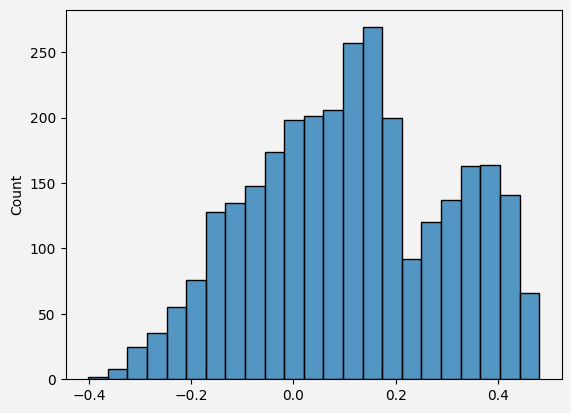

In [ ]:
silhouette_score_per_data = silhouette_samples(X_sample, agg.labels_)

print(pd.DataFrame(silhouette_score_per_data).describe())

sns.histplot(silhouette_score_per_data)

In [ ]:
# Calinski-Harabasz Score
calinski_harabasz_score(X_sample, agg.labels_)

np.float64(506.79167603231804)

In [ ]:
# Find optimal number of cluster
n_clusters = range(2, 11)
silhouette_scores = []
calinski_harabasz_scores = []

for n in n_clusters:
  print('Generating', n, 'clusters...')
  agg = AgglomerativeClustering(
    n_clusters=n,
    metric='euclidean',
    linkage='ward',
    compute_distances=True,
  )

  agg.fit(X_sample)

  silhouette_scores.append(silhouette_score(X_sample, agg.labels_))
  calinski_harabasz_scores.append(
    calinski_harabasz_score(X_sample, agg.labels_)
  )

Generating 2 clusters...
Generating 3 clusters...
Generating 4 clusters...
Generating 5 clusters...
Generating 6 clusters...
Generating 7 clusters...
Generating 8 clusters...
Generating 9 clusters...
Generating 10 clusters...


<Axes: >

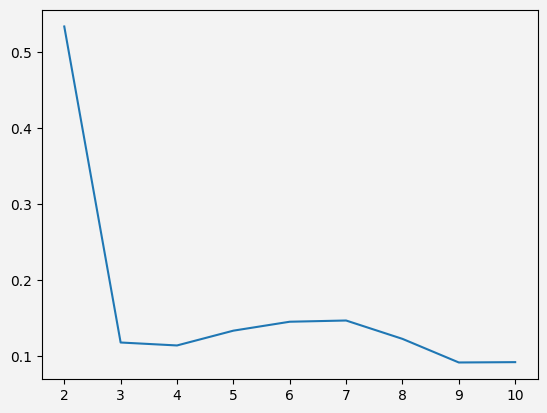

In [ ]:
# Evaluate
# silhouette_scores
sns.lineplot(x=n_clusters, y=silhouette_scores)

Berdasarkan metode silhoutte_scores didapatkan cluster terbaik adalah 2

<Axes: >

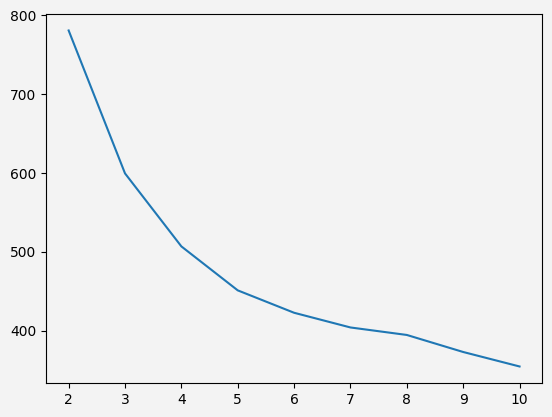

In [ ]:
# calinski_harabasz_scores
sns.lineplot(x=n_clusters, y=calinski_harabasz_scores)

Berdasarkan metode calinski_harabasz_scores didapatkan cluster terbaik adalah 2

In [ ]:
# Generate Final cluster
agg = AgglomerativeClustering(
  n_clusters=2,
  metric='euclidean',
  linkage='ward',
  compute_distances=True,
)

agg.fit(X_sample)

AgglomerativeClustering(compute_distances=True)

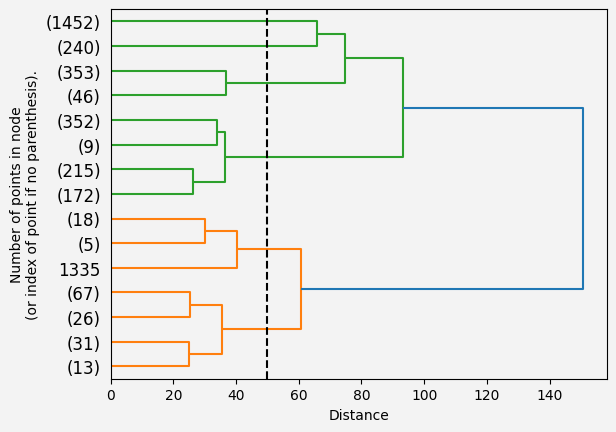

In [ ]:
# Visualize
# Dendogram
def plot_dendrogram(model, **kwargs):
  counts = np.zeros(model.children_.shape[0])
  n_samples = len(model.labels_)
  for i, merge in enumerate(model.children_):
    current_count = 0
    for child_idx in merge:
      if child_idx < n_samples:
        current_count += 1  # leaf node
      else:
        current_count += counts[child_idx - n_samples]
    counts[i] = current_count

  linkage_matrix = np.column_stack([
    model.children_,
    model.distances_,
    counts,
  ]).astype(float)

  dendrogram(linkage_matrix, orientation='right', **kwargs)

plot_dendrogram(agg, truncate_mode='level', p=3)
plt.xlabel('Distance')
plt.ylabel('Number of points in node\n(or index of point if no parenthesis).')

plt.axvline(x=50, color='black', linestyle='--')

plt.show()

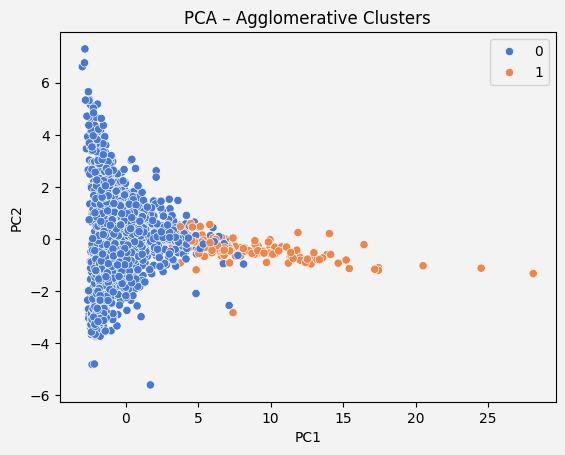

In [ ]:
# Generate 2D scatter plot using PCA
pca = PCA(n_components=2, random_state=11)
X_pca = pca.fit_transform(X_sample)

X_pca_1 = [row[0] for row in X_pca]
X_pca_2 = [row[1] for row in X_pca]

ax = sns.scatterplot(
  x=X_pca_1,
  y=X_pca_2,
  hue=agg.labels_,
  palette='muted',
)
ax.set(
  xlabel='PC1',
  ylabel='PC2',
)
plt.title('PCA – Agglomerative Clusters')
plt.show()

In [ ]:
# K-means
n_clusters = range(2, 11)
inertia_scores = []
silhouette_scores_kmeans = []
calinski_scores_kmeans = []

for n in n_clusters:
  print('Generating', n, 'clusters...')
  km_tmp = KMeans(
    n_clusters=n,
    algorithm='lloyd',
    random_state=11,
  )

  km_tmp.fit(X_transformed)

  inertia_scores.append(km_tmp.inertia_)
  silhouette_scores_kmeans.append(
    silhouette_score(X_transformed, km_tmp.labels_)
  )
  calinski_scores_kmeans.append(
    calinski_harabasz_score(X_transformed, km_tmp.labels_)
  )

Generating 2 clusters...
Generating 3 clusters...
Generating 4 clusters...
Generating 5 clusters...
Generating 6 clusters...
Generating 7 clusters...
Generating 8 clusters...
Generating 9 clusters...
Generating 10 clusters...


<Axes: >

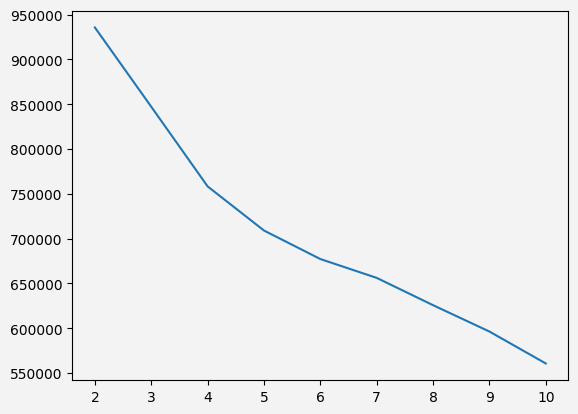

In [ ]:
# Evaluate
# Elbow method
sns.lineplot(x=n_clusters, y=inertia_scores)

Berdasarkan hasil elbow method adalah cluster terbaik adalah 4

<Axes: >

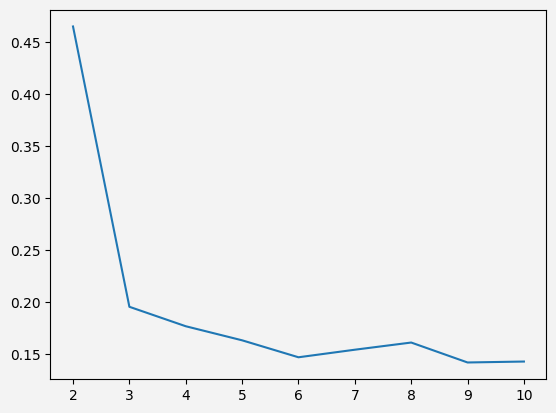

In [ ]:
# silhouette_scores_kmeans
sns.lineplot(x=n_clusters, y=silhouette_scores_kmeans)

Berdasarkan silhouete score k means cluster terbaik adalah 2

<Axes: >

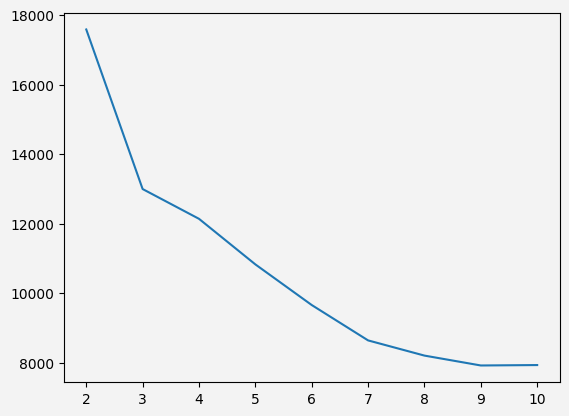

In [ ]:
# Calinski Harabasz scores
sns.lineplot(x=n_clusters, y=calinski_scores_kmeans)

Berdasarkan hasil calinski harabasz scores didapatkan cluster terbaik adalah cluster 2

In [ ]:
# Generate final cluster(k-means)
km = KMeans(
  n_clusters=2,
  algorithm='lloyd',
  random_state=11,
)

km.fit(X_transformed)

KMeans(n_clusters=2, random_state=11)

In [ ]:
#Visualized
km.cluster_centers_

array([[ 1.81941364,  0.19663355,  2.20948718,  2.13009234,  1.90442908,
         2.09046447,  2.16763136, -0.78610444, -0.62729258, -0.55055682,
         1.36940834,  0.56585588,  2.02167178,  0.79016373,  0.4174669 ,
        -0.62129373,  1.6509384 ,  0.10557459, -0.05111509],
       [-0.20398815, -0.02204607, -0.24772222, -0.23882067, -0.21351987,
        -0.23437769, -0.24302945,  0.08813608,  0.07033049,  0.06172707,
        -0.15353467, -0.06344236, -0.22666483, -0.0885912 , -0.04680535,
         0.06965791, -0.18509912, -0.01183676,  0.0057309 ]])

In [ ]:
pca.transform(km.cluster_centers_)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


array([[ 6.04601808, -0.22589392],
       [-0.69005084,  0.01145956]])

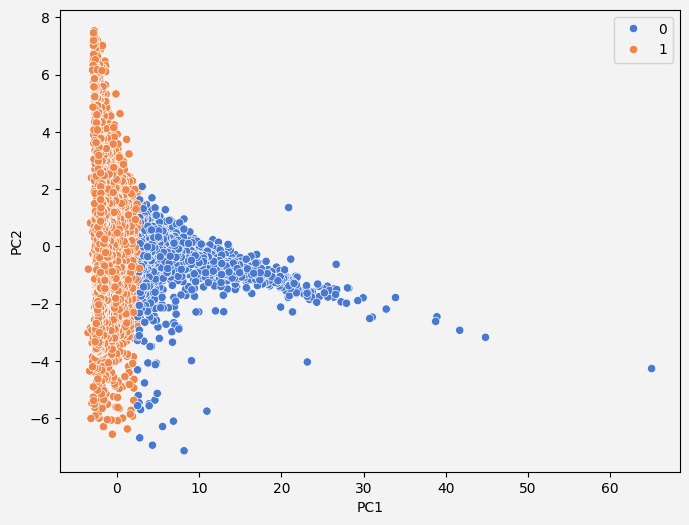

In [ ]:
pca = PCA(n_components=2, random_state=11)
X_pca = pca.fit_transform(X_transformed)

plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=km.labels_,
    palette='muted',
)
ax.set(
  xlabel='PC1',
  ylabel='PC2',
)
plt.show()

Berdasarkan metode agglomerative dan k means dapat terlihat bahwa cluster oranye dan cluster biru telah terpisah dengan sangat baik yang menandakan bahwa proses clustering sudah sangat baik.

Namun, dalam hal ini kita menggunakan k means dikarenakan untuk agglomerative dikarenakan kendala RAM hanya bisa menggambil sampel, namun untuk k means menggambil seluruh data sehingga data menjadi lebih valid

In [ ]:
# Interpretasi
X_with_cluster = X.copy()
X_with_cluster['cluster_kmeans'] = km.labels_

X_with_cluster.head()

,FFP_TIER,AGE,FLIGHT_COUNT,BP_SUM,SUM_YR_1,SUM_YR_2,SEG_KM_SUM,LAST_TO_END,AVG_INTERVAL,MAX_INTERVAL,EXCHANGE_COUNT,avg_discount,Points_Sum,Point_NotFlight,TENURE_DAYS,RECENCY_DAYS,FLIGHT_FREQUENCY,AVG_DISTANCE_PER_FLIGHT,UNUSED_POINT_RATIO,cluster_kmeans
0,6,31.0,210,505308,239560.0,234188.0,580717,1,3.483254,18,34,0.961639,619760,50,2706,0,28.345344,2765.319048,0.000081,0
1,6,42.0,140,362480,171483.0,167434.0,293678,7,5.194245,17,29,1.252314,415768,33,2597,6,19.690027,2097.700000,0.000079,0
2,6,40.0,135,351159,163618.0,164982.0,283712,11,5.298507,18,20,1.254676,406361,26,2615,10,18.856119,2101.570370,0.000064,0
3,5,64.0,23,337314,116350.0,125500.0,281336,97,27.863636,73,11,1.090870,372204,12,2047,95,4.103933,12232.000000,0.000032,0
4,6,48.0,152,273844,124560.0,130702.0,309928,5,4.788079,47,27,0.970658,338813,39,1816,4,30.571586,2039.000000,0.000115,0


<Axes: ylabel='FLIGHT_COUNT'>

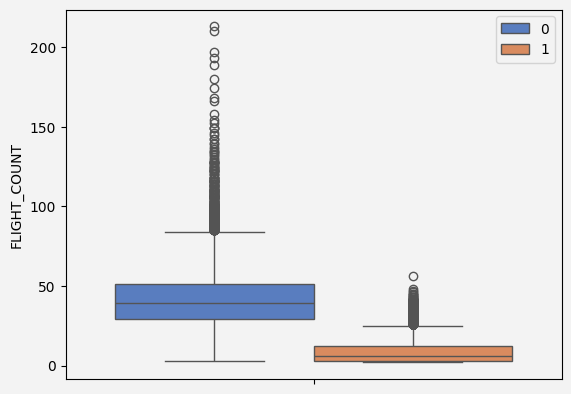

In [ ]:
sns.boxplot(y=X_with_cluster['FLIGHT_COUNT'], hue=km.labels_, palette='muted')


Berdasarkan bloxplot terkait flight count:
-  cluster berwarna biru menggambarkan customer yang sering melakukan penerbangan

- cluster berwarna oranye menggambarkan customer yangjarang melakukan penerbangan

<Axes: ylabel='SEG_KM_SUM'>

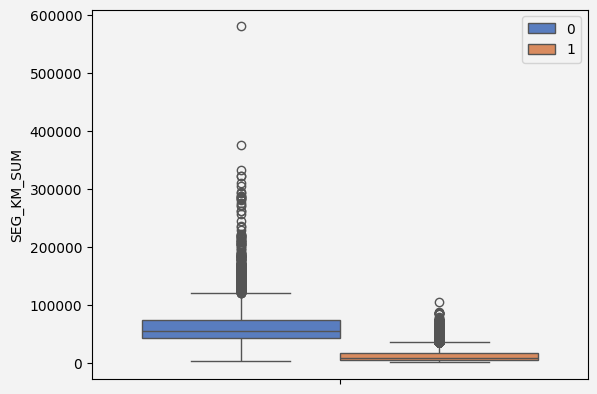

In [ ]:
sns.boxplot(y=X_with_cluster['SEG_KM_SUM'], hue=km.labels_, palette='muted')

Berdasarkan bloxplot terkait SEG_KM_SUM:
- cluster biru menggambarkan custmer dengan jarak penerbangan jauh (penerbangan bisnis/international)
- cluster oranye menggambarkan customer dengan jarak penerbangan dekat

<Axes: ylabel='RECENCY_DAYS'>

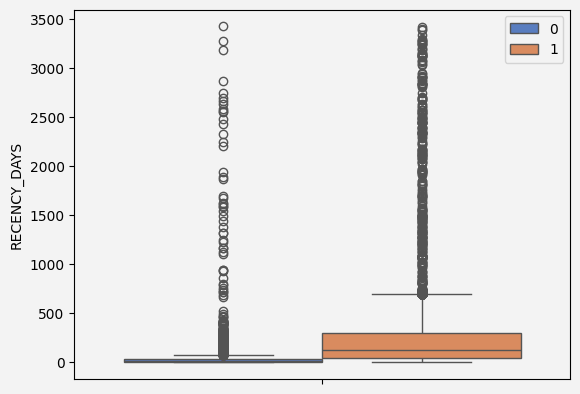

In [ ]:
sns.boxplot(y=X_with_cluster['RECENCY_DAYS'], hue=km.labels_, palette='muted')

Berdasarkan hasil bloxplot terkait RECENCY_DAYS:
- cluster biru menggambarkan customer yang masih aktif melakukan penerbangan
- cluster oranye menggambarkan customer yang sudah lama tidak melakukan penerbangan

<Axes: ylabel='TENURE_DAYS'>

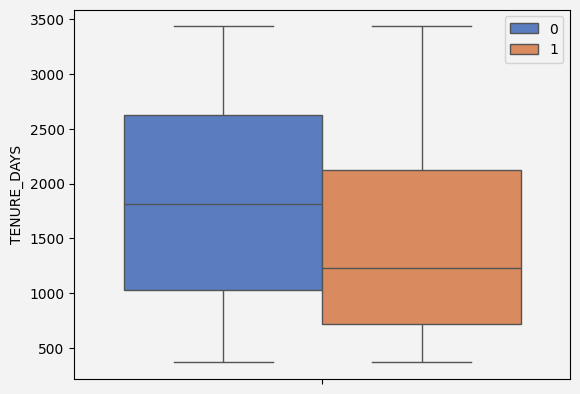

In [ ]:
sns.boxplot(y=X_with_cluster['TENURE_DAYS'], hue=km.labels_, palette='muted')

Berdasarkan hasil bloxplot terkait TENURE_DAYS:
- cluster biru menggambarkan customer yang lebih lama sebagai member
- cluster oranye menggambarkan customer baru atau pasif sebagai member

<Axes: ylabel='Points_Sum'>

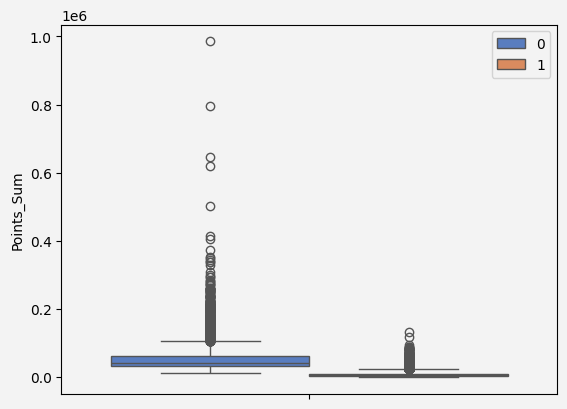

In [ ]:
sns.boxplot(y=X_with_cluster['Points_Sum'], hue=km.labels_, palette='muted')

Berdasarkan hasil bloxplot point sum didapatkan:
- cluster biru menggambarkan customer yang mendapatkan jumlah point yang banyak
- cluster oranye menggambarkan customer yang mendapatkan jumlah point yang rendah

<Axes: ylabel='avg_discount'>

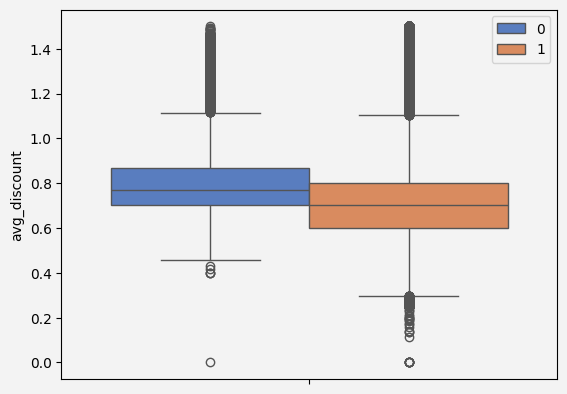

In [ ]:
sns.boxplot(y=X_with_cluster['avg_discount'], hue=km.labels_, palette='muted')

Berdasarkan hasil bloxplot avg score didapatkan:
- cluster biru menggambarkan customer yang mendapat lebih banyak discount
- cluster oranye menggambarkan customer yang lebih rendah mendapatkan harga discount

<Axes: ylabel='EXCHANGE_COUNT'>

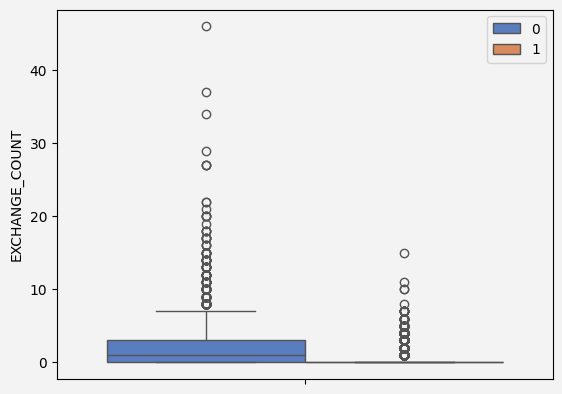

In [ ]:
sns.boxplot(y=X_with_cluster['EXCHANGE_COUNT'], hue=km.labels_, palette='muted')

Berdasarkan hasil bloxplot excange count didapatkan:
- cluster biru menggambarkan customer yang sering menukar point
- cluster oranye menggambarkan customer yang hampir tidak menukar point

<Axes: ylabel='SUM_YR_1'>

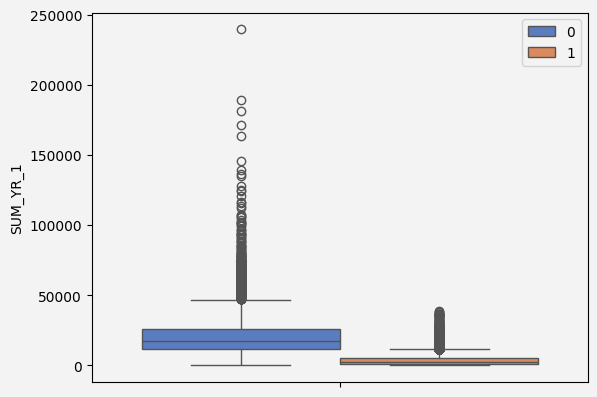

In [ ]:
sns.boxplot(y=X_with_cluster['SUM_YR_1'], hue=km.labels_, palette='muted')

Berdasarkan hasil bloxplot SUM YR 1 didapatkan:
- cluster biru menggambarkan customer yang berkontribusi dalam revenue tinggi pada tahun 1
- cluster oranye menggambarkan  customer yang belum berkontribusi dalam revenue tinggi pada tahun 1

<Axes: ylabel='SUM_YR_2'>

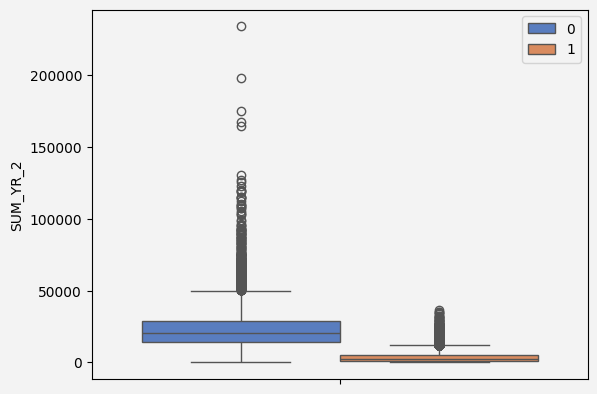

In [ ]:
sns.boxplot(y=X_with_cluster['SUM_YR_2'], hue=km.labels_, palette='muted')

Berdasarkan hasil bloxplot SUM YR 1 didapatkan:
- cluster biru menggambarkan customer yang berkontribusi dalam revenue tinggi pada tahun 2
- cluster oranye menggambarkan  customer yang belum berkontribusi dalam revenue tinggi pada tahun 2

Berdasarkan hasil EDA tersebut dapat ditarik nama untuk cluster biru dan cluster oranye yaitu
- cluster biru = High Value Loyal Flyers
- cluster oranye = Low Engagement Casual Travelers

Business insight and recommendation
- Cluster High Value Loyal Flyers

  --Business insight:
  - customer yang sering melakukan penerbangan
  - sering melakukan penerbangan jarak jauh
  - sudah alam menjadi member
  - seringnya melakukan penerangan sehingga mendapatkan banyak poin dan serng menggunakan point
  - masih aktif

  --Recommendation:
  - Berikan keuntungan eksklusif dengan lounge, prioritas boarding, penambahan bagasi tambahan secara gratis
  - buat program loyalitas berdasarkan frekuensi penerbangan customer dan total spending customer
  - Promo khusus untuk business travelers


- Cluster Engagement Casul Traveler

  -- Business insight
  - jarang melakukan penerbangan dan melakukan penerbangan jarak pendek
  - sudah lama tidak terbang
  - jarang menggunakan point
  - customer baru

  -- recommendation
  - berikan promo serta diskon menarik untuk custoemer
  - buatkan remainder untuk masa berlaku point
  - buat kampanye yang dapat menagajak customer melakukan penerbangan kembali

In [ ]:
df.to_csv("data_flight.csv", index=False)

from google.colab import files
files.download("data_flight.csv")